In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import itertools
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
warnings.filterwarnings('ignore')

In [5]:
# --------------------------------------------------
# Load data  (adjust paths if needed)
# --------------------------------------------------
train = pd.read_csv('../../../data/rossmann-store-sales/train.csv', low_memory=False, parse_dates=['Date'])
store = pd.read_csv('../../../data/rossmann-store-sales/store.csv')

# Merge store metadata
train = train.merge(store, on='Store', how='left')

# Basic cleaning
train = train[train['Open'] == 1]          # keep only open days
train = train[train['Sales'] > 0]          # remove zero-sales rows
train.sort_values('Date', inplace=True)

print(f"Shape: {train.shape}")
print(train.dtypes)
train.head()

Shape: (844338, 18)
Store                                 int64
DayOfWeek                             int64
Date                         datetime64[ns]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                         object
SchoolHoliday                         int64
StoreType                            object
Assortment                           object
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                        object
dtype: object


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1017190,1097,2,2013-01-01,5961,1405,1,0,a,1,b,b,720.0,3.0,2002.0,0,NaN,NaN,NaN
1016179,85,2,2013-01-01,4220,619,1,0,a,1,b,a,1870.0,10.0,2011.0,0,NaN,NaN,NaN
1016353,259,2,2013-01-01,6851,1444,1,0,a,1,b,b,210.0,NaN,NaN,0,NaN,NaN,NaN
1016356,262,2,2013-01-01,17267,2875,1,0,a,1,b,a,1180.0,5.0,2013.0,0,NaN,NaN,NaN
1016368,274,2,2013-01-01,3102,729,1,0,a,1,b,b,3640.0,NaN,NaN,1,10.0,2013.0,"Jan,Apr,Jul,Oct"


In [6]:
# --------------------------------------------------
# We'll tune on a single store (Store 1 is a good default).
# Prophet expects columns named 'ds' and 'y'.
# --------------------------------------------------
STORE_ID = 1

df = train[train['Store'] == STORE_ID][['Date', 'Sales']].copy()
df.rename(columns={'Date': 'ds', 'Sales': 'y'}, inplace=True)
df.sort_values('ds', inplace=True)

print(f"Date range: {df['ds'].min()} → {df['ds'].max()}")
print(f"Rows: {len(df)}")
df.tail()

Date range: 2013-01-02 00:00:00 → 2015-07-31 00:00:00
Rows: 781


,ds,y
4460,2015-07-27,6102
3345,2015-07-28,5011
2230,2015-07-29,4782
1115,2015-07-30,5020
0,2015-07-31,5263


In [7]:
# --------------------------------------------------
# Hold out the last 6 weeks as validation set
# --------------------------------------------------
split_date = df['ds'].max() - pd.Timedelta(weeks=6)

train_df = df[df['ds'] <= split_date].copy()
val_df   = df[df['ds'] >  split_date].copy()

print(f"Train rows : {len(train_df)}  ({train_df['ds'].min()} → {train_df['ds'].max()})")
print(f"Val   rows : {len(val_df)}  ({val_df['ds'].min()} → {val_df['ds'].max()})")

Train rows : 745  (2013-01-02 00:00:00 → 2015-06-19 00:00:00)
Val   rows : 36  (2015-06-20 00:00:00 → 2015-07-31 00:00:00)


In [8]:
def evaluate(actual, predicted):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'MAPE%': round(mape, 2)}

In [9]:
# --------------------------------------------------
# Parameters to tune
#   changepoint_prior_scale  : flexibility of trend (higher = more flexible)
#   seasonality_prior_scale  : strength of seasonality
#   seasonality_mode         : additive vs multiplicative
#   yearly_seasonality       : on/off
# --------------------------------------------------

param_grid = {
    'changepoint_prior_scale' : [0.01, 0.1, 0.5],
    'seasonality_prior_scale' : [1.0, 10.0, 20.0],
    'seasonality_mode'        : ['additive', 'multiplicative'],
    'yearly_seasonality'      : [True, False],
}

keys   = list(param_grid.keys())
combos = list(itertools.product(*param_grid.values()))
print(f"Total combinations to evaluate: {len(combos)}")

Total combinations to evaluate: 36


In [10]:
results = []

for combo in combos:
    params = dict(zip(keys, combo))

    m = Prophet(
        changepoint_prior_scale = params['changepoint_prior_scale'],
        seasonality_prior_scale = params['seasonality_prior_scale'],
        seasonality_mode        = params['seasonality_mode'],
        yearly_seasonality      = params['yearly_seasonality'],
        weekly_seasonality      = True,
        daily_seasonality       = False,
    )
    m.fit(train_df)

    # Predict over validation horizon
    future   = m.make_future_dataframe(periods=len(val_df))
    forecast = m.predict(future)

    # Align forecast with validation dates
    pred = forecast[forecast['ds'].isin(val_df['ds'])][['ds', 'yhat']].copy()
    merged = val_df.merge(pred, on='ds')

    metrics = evaluate(merged['y'].values, merged['yhat'].values)
    metrics.update(params)
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values('MAPE%')
print("✅ Grid search complete!")
results_df.head(10)

17:24:41 - cmdstanpy - INFO - Chain [1] start processing
17:24:42 - cmdstanpy - INFO - Chain [1] done processing
17:24:42 - cmdstanpy - INFO - Chain [1] start processing
17:24:42 - cmdstanpy - INFO - Chain [1] done processing
17:24:43 - cmdstanpy - INFO - Chain [1] start processing
17:24:43 - cmdstanpy - INFO - Chain [1] done processing
17:24:44 - cmdstanpy - INFO - Chain [1] start processing
17:24:44 - cmdstanpy - INFO - Chain [1] done processing
17:24:44 - cmdstanpy - INFO - Chain [1] start processing
17:24:44 - cmdstanpy - INFO - Chain [1] done processing
17:24:45 - cmdstanpy - INFO - Chain [1] start processing
17:24:45 - cmdstanpy - INFO - Chain [1] done processing
17:24:45 - cmdstanpy - INFO - Chain [1] start processing
17:24:45 - cmdstanpy - INFO - Chain [1] done processing
17:24:46 - cmdstanpy - INFO - Chain [1] start processing
17:24:46 - cmdstanpy - INFO - Chain [1] done processing
17:24:46 - cmdstanpy - INFO - Chain [1] start processing
17:24:46 - cmdstanpy - INFO - Chain [1]

✅ Grid search complete!


,MAE,RMSE,MAPE%,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,yearly_seasonality
35,558.28,726.90,12.30,0.50,20.0,multiplicative,False
31,557.81,724.93,12.31,0.50,10.0,multiplicative,False
27,559.20,728.33,12.31,0.50,1.0,multiplicative,False
29,555.71,713.55,12.40,0.50,10.0,additive,False
25,554.98,708.05,12.43,0.50,1.0,additive,False
33,554.99,707.41,12.44,0.50,20.0,additive,False
26,596.49,716.28,13.87,0.50,1.0,multiplicative,True
8,598.56,723.31,13.87,0.01,20.0,additive,True
0,598.97,723.25,13.88,0.01,1.0,additive,True
30,596.90,716.31,13.89,0.50,10.0,multiplicative,True


In [11]:
best_params = results_df.iloc[0]
print("=" * 50)
print("BEST PARAMETER COMBINATION")
print("=" * 50)
print(best_params.to_string())

BEST PARAMETER COMBINATION
MAE                                558.28
RMSE                                726.9
MAPE%                                12.3
changepoint_prior_scale               0.5
seasonality_prior_scale              20.0
seasonality_mode           multiplicative
yearly_seasonality                  False


17:28:03 - cmdstanpy - INFO - Chain [1] start processing
17:28:03 - cmdstanpy - INFO - Chain [1] done processing


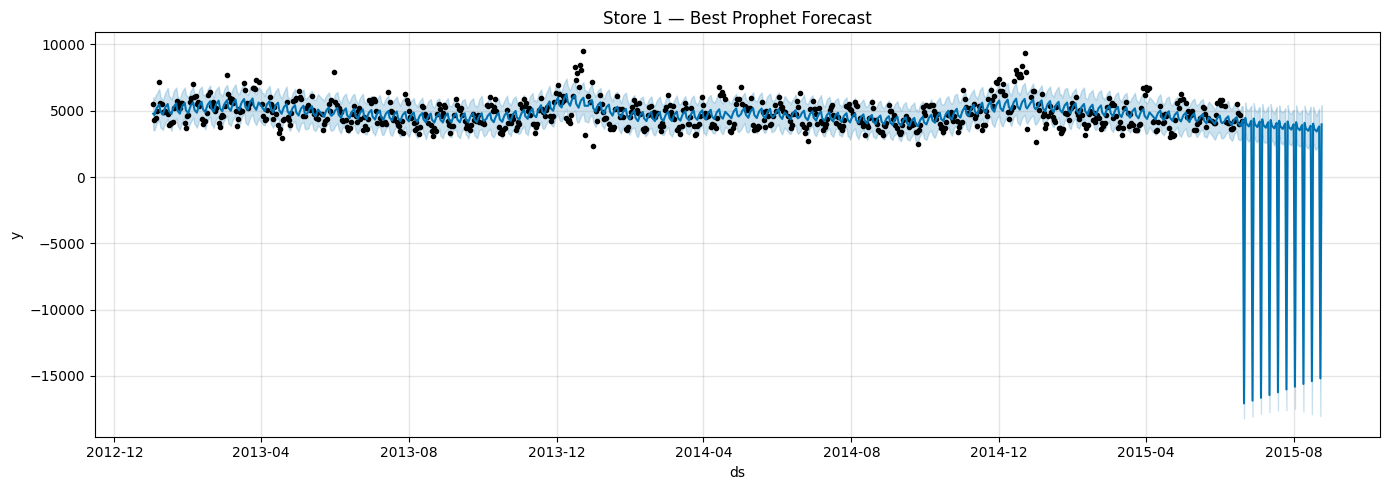

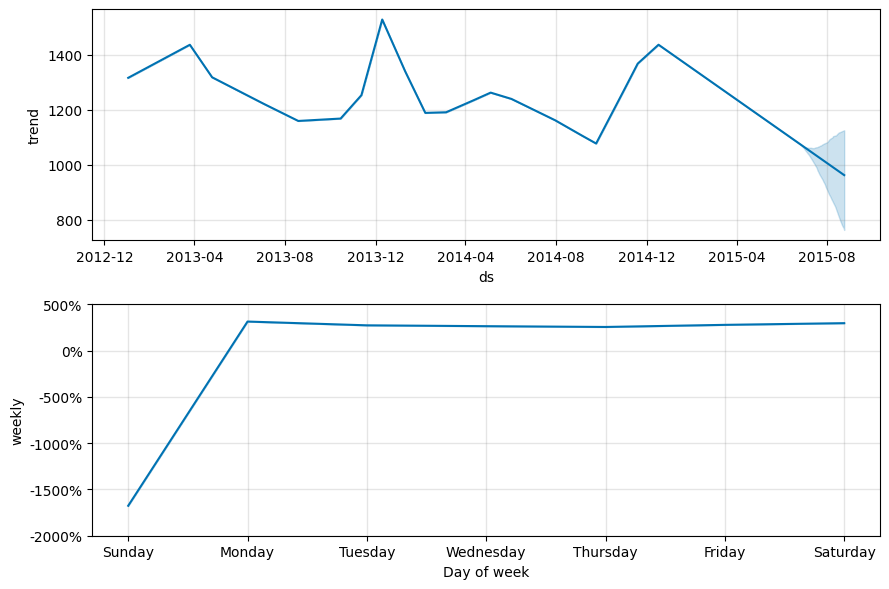

In [12]:
best = Prophet(
    changepoint_prior_scale = best_params['changepoint_prior_scale'],
    seasonality_prior_scale = best_params['seasonality_prior_scale'],
    seasonality_mode        = best_params['seasonality_mode'],
    yearly_seasonality      = bool(best_params['yearly_seasonality']),
    weekly_seasonality      = True,
    daily_seasonality       = False,
)
best.fit(train_df)

future   = best.make_future_dataframe(periods=len(val_df) + 30)  # +30 future days
forecast = best.predict(future)

fig1 = best.plot(forecast, figsize=(14, 5))
plt.title(f"Store {STORE_ID} — Best Prophet Forecast")
plt.tight_layout()
plt.show()

fig2 = best.plot_components(forecast)
plt.tight_layout()
plt.show()

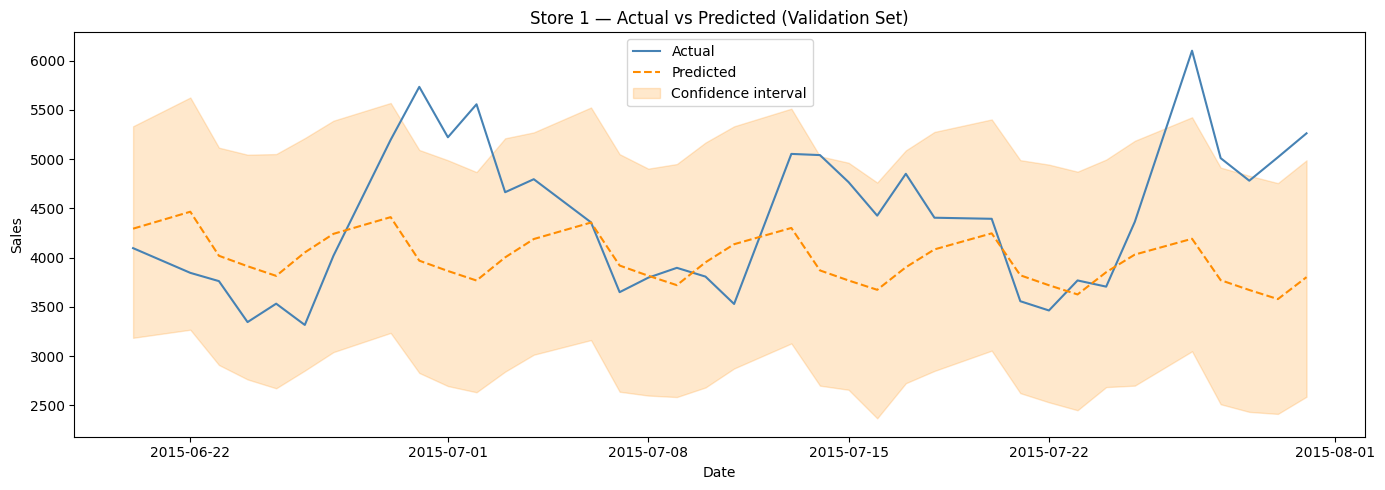


Validation Metrics:  {'MAE': 679.63, 'RMSE': 866.08, 'MAPE%': 14.36}


In [13]:
pred_val = forecast[forecast['ds'].isin(val_df['ds'])][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
merged   = val_df.merge(pred_val, on='ds')

plt.figure(figsize=(14, 5))
plt.plot(merged['ds'], merged['y'],    label='Actual',    color='steelblue')
plt.plot(merged['ds'], merged['yhat'], label='Predicted', color='darkorange', linestyle='--')
plt.fill_between(merged['ds'], merged['yhat_lower'], merged['yhat_upper'],
                 alpha=0.2, color='darkorange', label='Confidence interval')
plt.title(f"Store {STORE_ID} — Actual vs Predicted (Validation Set)")
plt.xlabel('Date'); plt.ylabel('Sales')
plt.legend(); plt.tight_layout(); plt.show()

metrics = evaluate(merged['y'].values, merged['yhat'].values)
print(f"\nValidation Metrics:  {metrics}")

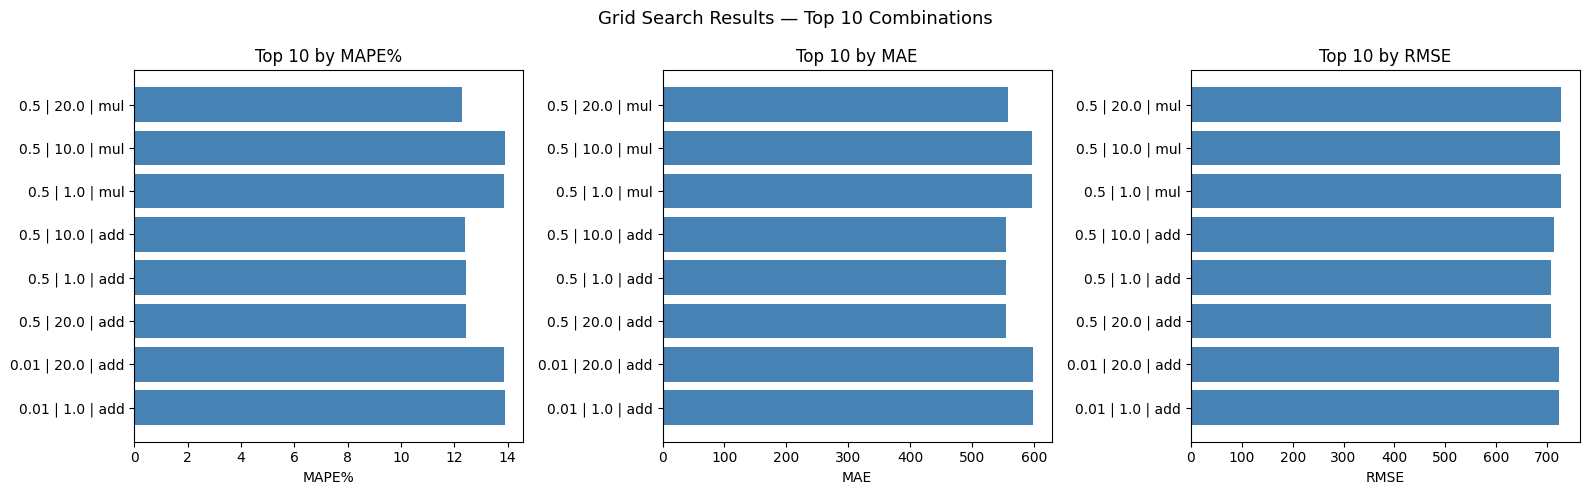

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['MAPE%', 'MAE', 'RMSE']):
    top10 = results_df.head(10).copy()
    top10['label'] = (top10['changepoint_prior_scale'].astype(str) + ' | ' +
                      top10['seasonality_prior_scale'].astype(str) + ' | ' +
                      top10['seasonality_mode'].str[:3])
    ax.barh(top10['label'], top10[metric], color='steelblue')
    ax.set_title(f'Top 10 by {metric}')
    ax.set_xlabel(metric)
    ax.invert_yaxis()

plt.suptitle('Grid Search Results — Top 10 Combinations', fontsize=13)
plt.tight_layout()
plt.show()